In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                            Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           7148        170                1  
ssssws/chocolate-sales-dataset-2023-2024                         Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000          10870        170                1  
borovai0/student-performance-analytics-dataset                   Student Performance Analytics Dataset                   264103  2026-04-01 19:54:36.470000            794         25               

In [1]:
!kaggle datasets download -d camnugent/california-housing-prices

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
100% 400k/400k [00:00<00:00, 119MB/s]



In [2]:
!unzip california-housing-prices.zip

Archive:  california-housing-prices.zip
  inflating: housing.csv             


In [3]:
import pandas as pd

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
print("information of dataset",df.info())
print("describing the dataset",df.describe())
print("checking null values",df.isnull().sum())
print("correlation between features",df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
information of dataset None
describing the dataset           longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   26

In [6]:
df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)

/tmp/ipykernel_10416/2576143001.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)


In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Reload the DataFrame to ensure 'ocean_proximity' is present
# and apply any preceding necessary transformations like filling nulls for total_bedrooms
# This step is crucial if the notebook is run out of order or multiple times on this cell.
df = pd.read_csv("housing.csv")
df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)

ohe=OneHotEncoder(sparse_output=False)
ohe.fit(df[['ocean_proximity']])
encoded_data=pd.DataFrame(ohe.fit_transform(df[['ocean_proximity']]),columns=ohe.get_feature_names_out())
df.reset_index(drop=True,inplace=True)
encoded_data.reset_index(drop=True,inplace=True)
df.drop('ocean_proximity',axis=1,inplace=True)
df=pd.concat([df,encoded_data],axis=1)


/tmp/ipykernel_10416/4247969471.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(),inplace=True)


In [8]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0.0,1.0,0.0,0.0,0.0


In [9]:
from sklearn.model_selection import train_test_split

X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
outlier_cols = []

for col in X_train.select_dtypes(include=['int64', 'float64']).columns:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if ((X_train[col] < lower) | (X_train[col] > upper)).any():
        outlier_cols.append(col)

print("Columns with outliers:", outlier_cols)

Columns with outliers: ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
X_train.skew()[X_train.skew() > 1].index

Index(['total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

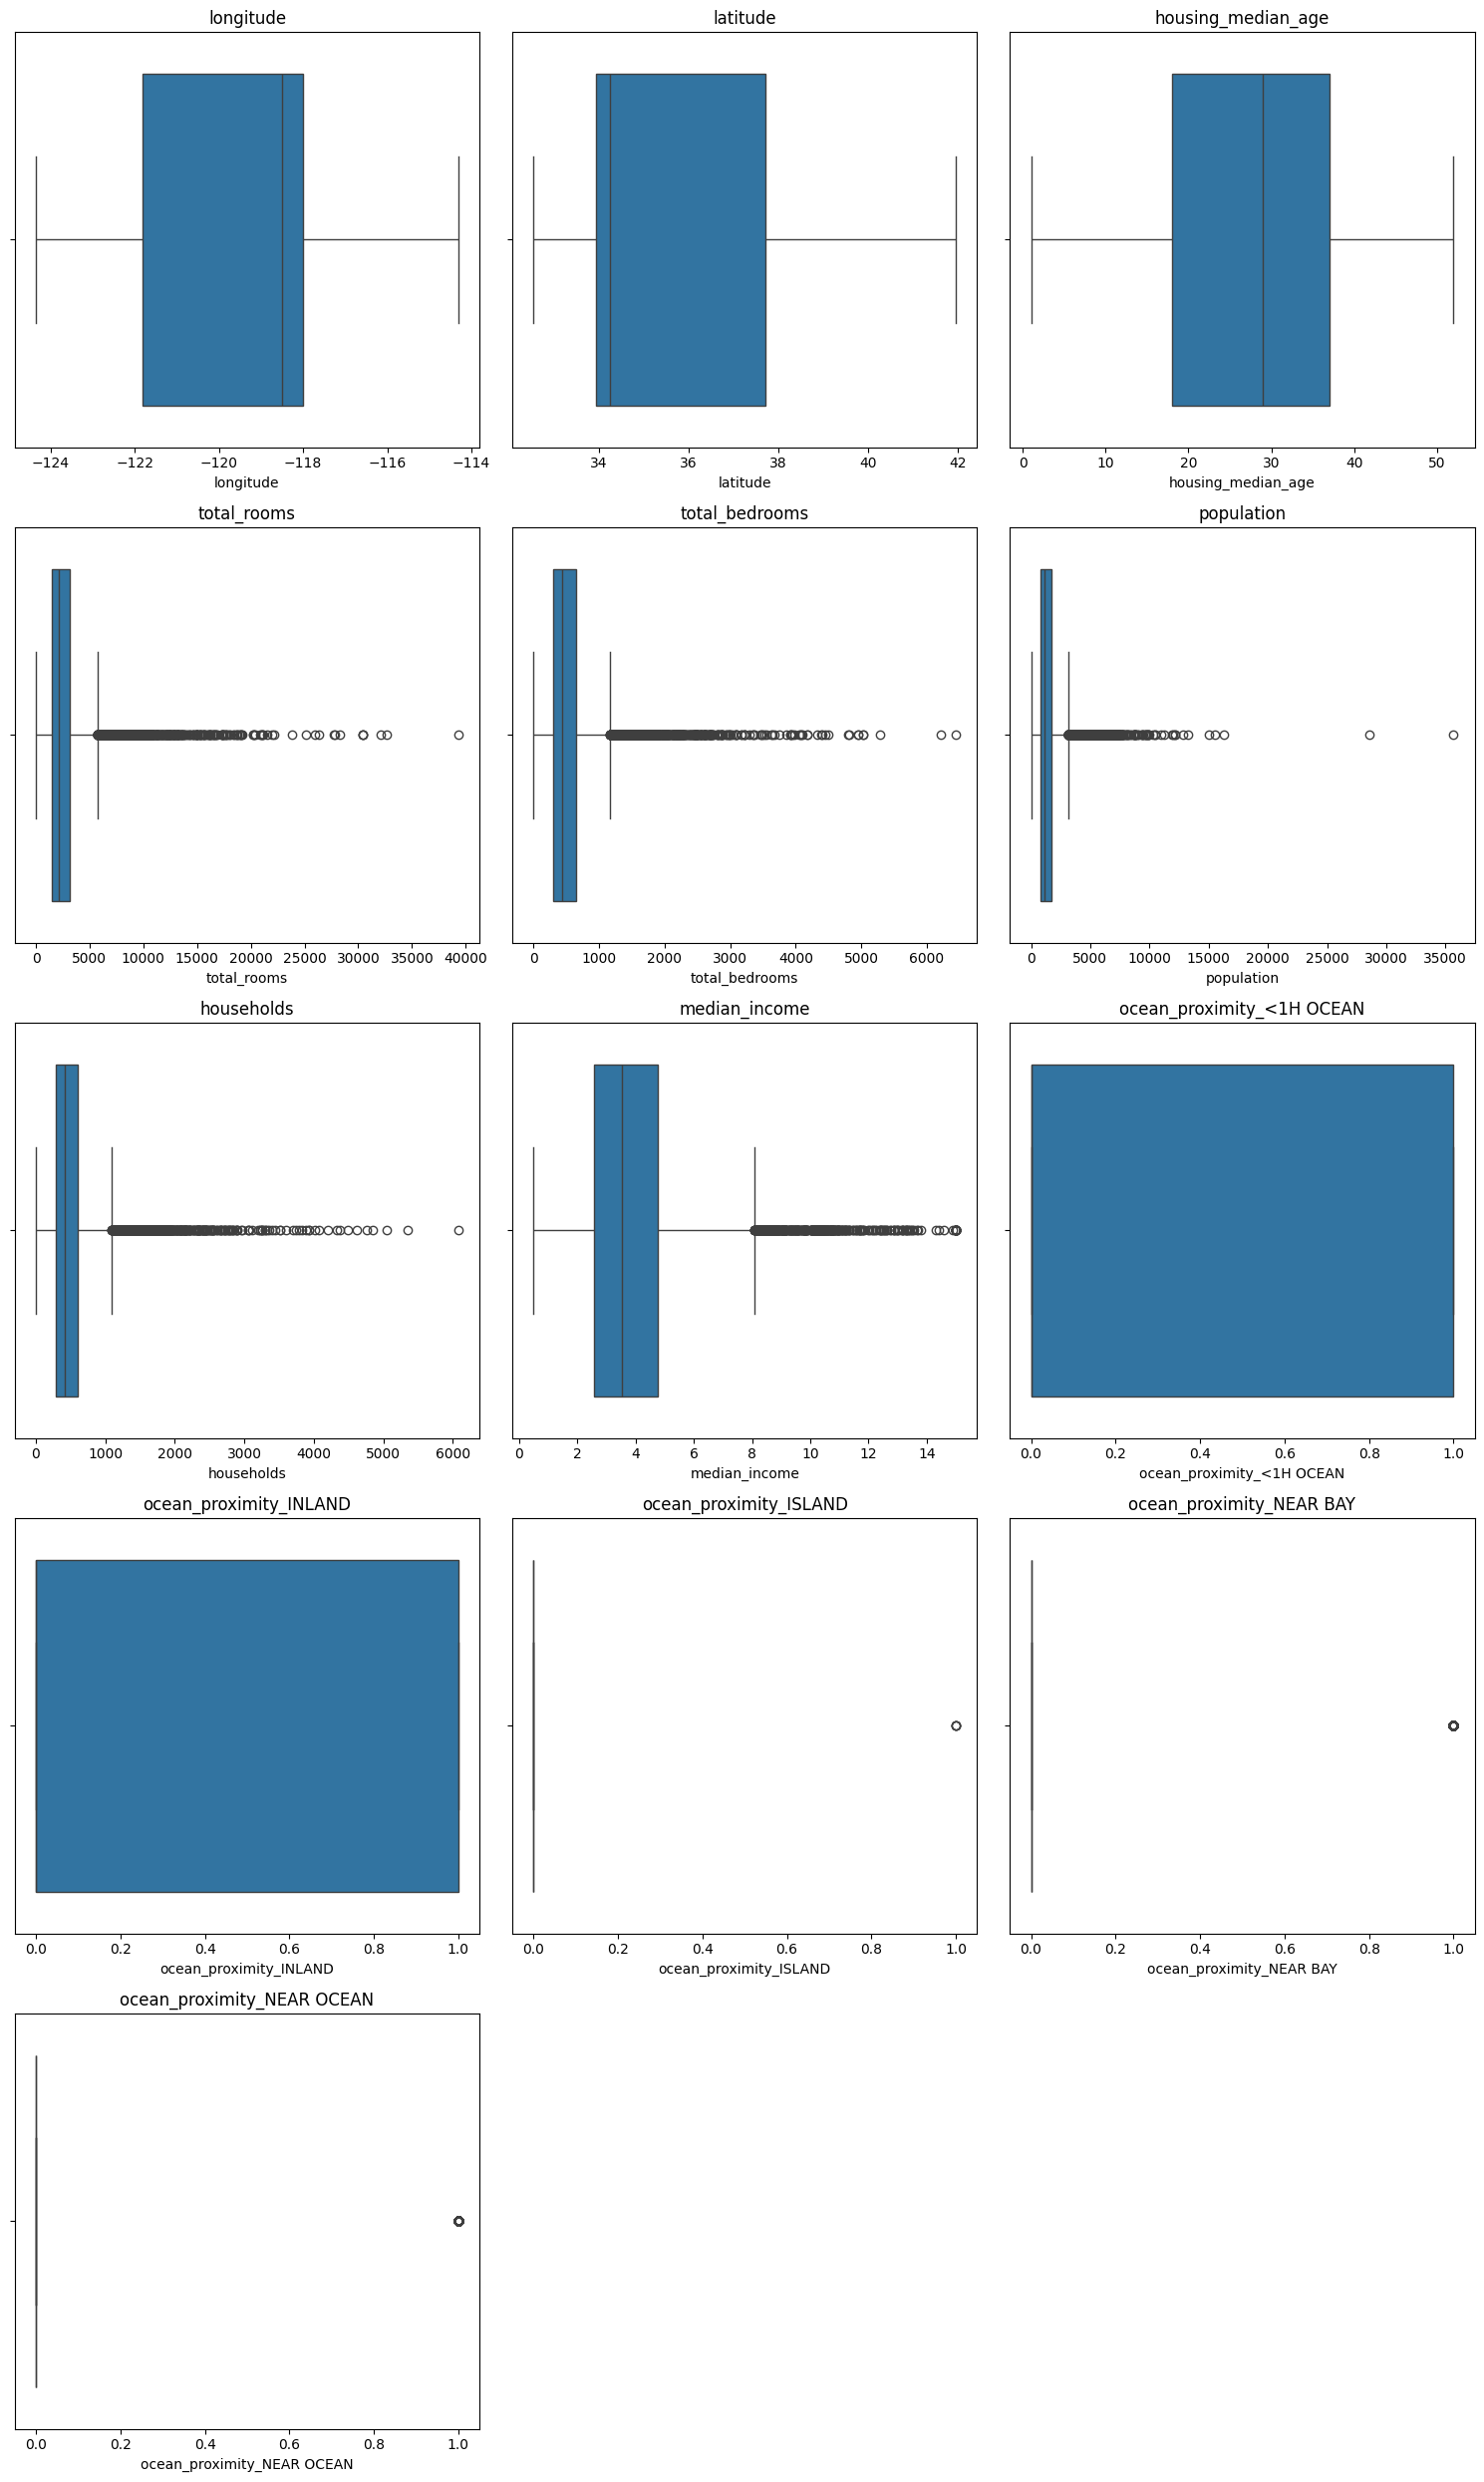

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

cols = X_train.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=X_train[col])
    plt.title(col)

plt.tight_layout()
plt.show()

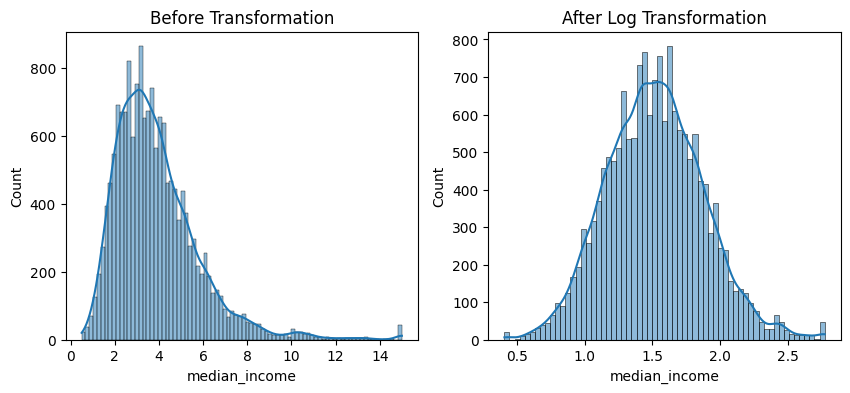

In [14]:
import numpy as np
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(X_train['median_income'], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(np.log1p(X_train['median_income']), kde=True)
plt.title("After Log Transformation")

plt.show()

In [15]:
import numpy as np
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
skewed_cols = X_train[numeric_cols].skew()[X_train[numeric_cols].skew() > 1].index
print(skewed_cols)
for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

Index(['total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LinearRegression

linear_model=LinearRegression()
linear_model.fit(X_train_scaled,y_train)
print(linear_model.score(X_train_scaled,y_train))
print(linear_model.score(X_test_scaled,y_test))

0.6433902159615219
0.5989322743746193


In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=100)
ridge.fit(X_train_scaled, y_train)

print(ridge.score(X_train_scaled, y_train))
print(ridge.score(X_test_scaled, y_test))

0.6421578166522376
0.6081386061467895


In [19]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100)
lasso.fit(X_train_scaled, y_train)

print(lasso.score(X_train_scaled, y_train))
print(lasso.score(X_test_scaled, y_test))

0.64325720032158
0.6017659813177452


In [20]:
from sklearn.preprocessing import PolynomialFeatures

pf = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = pf.fit_transform(X_train_scaled)
X_test_poly = pf.transform(X_test_scaled)

In [21]:
model = Ridge(alpha=100)
model.fit(X_train_poly, y_train)
print(model.score(X_train_poly,y_train))
print(model.score(X_test_poly, y_test))

0.7376256378480712
0.7045043204851456


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

print("Train:", rf.score(X_train, y_train))
print("Test:", rf.score(X_test, y_test))

Train: 0.8446169954730461
Test: 0.7803956795978754


In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

print("Train:", gb.score(X_train, y_train))
print("Test:", gb.score(X_test, y_test))

Train: 0.8278108640092927
Test: 0.7928052307028628
